In [14]:
# ============================================================================
# PHASE 1 — BASELINE CNN TRAINING (FULL MNIST & CIFAR-10)
# ----------------------------------------------------------------------------
# Dissertation : Few-Shot Image Classification Can Intelligent Data Curation Replace Large Training Datasets?
# Author       : Naresh  (Student ID 3457063)
# Supervisor   : Dr. Patrick Maier, University of Stirling
# Platform     : Kaggle, GPU T4 x2
#
# PURPOSE OF PHASE 1
#   Establish the "upper-bound" accuracy of the FIXED architecture when it is
#   trained on the FULL dataset. Every later phase trains the SAME network on
#   curated subsets (0.2%-5%); those results only mean something relative to
#   this baseline. So Phase 1 is the reference line on every plot to come.

# -- 1. IMPORTS -------------------------------------------------------------

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import f1_score, confusion_matrix

import random
import os

In [15]:
# -- 2. REPRODUCIBILITY -----------------------------------------------------
# We run the SAME experiment under 5 fixed seeds and report mean +/- std.

SEEDS = [42, 123, 456, 789, 1011]   # fixed across ALL phases of the project


def set_seed(seed):
    """Seed every source of randomness that affects a training run."""
    random.seed(seed)                       # Python RNG (shuffling, etc.)
    np.random.seed(seed)                    # NumPy RNG (sklearn, transforms)
    torch.manual_seed(seed)                 # PyTorch CPU RNG (weight init)
    torch.cuda.manual_seed_all(seed)        # PyTorch GPU RNG, all devices
    # Forbid cuDNN from choosing faster but non-deterministic kernels:
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def seed_worker(worker_id):
    """Seed each DataLoader worker process so augmentation/shuffle is reproducible.

    Each worker is a separate process with its own RNG; without this they would
    augment and order batches differently on every run even when the main seed
    is fixed. This closes the reproducibility gap left by num_workers > 0.
    """
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [16]:
# -- 3. DEVICE --------------------------------------------------------------
# Use GPU if available (Kaggle T4), otherwise fall back to CPU.

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [17]:
# -- 4. CNN ARCHITECTURE (FIXED for every phase) ----------------------------
# The SAME architecture is used for both MNIST and CIFAR-10. Keeping the model identical across all experiments means any difference in accuracy comes from the DATA SELECTION STRATEGY, not the model.
#   Block 1: Conv(in_channels -> 32)  -> BatchNorm -> ReLU -> MaxPool
#   Block 2: Conv(32 -> 64)           -> BatchNorm -> ReLU -> MaxPool
#   Block 3: Conv(64 -> 128)          -> BatchNorm -> ReLU -> MaxPool
#   Classifier: AdaptiveAvgPool(2x2) -> Flatten -> FC(512 -> 256)
#               -> ReLU -> Dropout -> FC(256 -> num_classes)
#
# in_channels = 1 for MNIST (grayscale), 3 for CIFAR-10 (RGB); num_classes = 10.

class SimpleCNN(nn.Module):
    def __init__(self, in_channels, num_classes):
        super(SimpleCNN, self).__init__()

        # Convolutional block 1
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)              # halves spatial size
        )

        # Convolutional block 2
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        # Convolutional block 3
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        # Adaptive pool fixes the output at 2x2 regardless of input size, so the one model handles both 28x28 MNIST and 32x32 CIFAR-10 without a second architecture. Output here is (128, 2, 2) -> 512 features into the Fully connected Layer.
        self.adaptive_pool = nn.AdaptiveAvgPool2d((2, 2))

        # Fully connected classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 2 * 2, 256),
            nn.ReLU(),
            nn.Dropout(0.5),               # regularisation to limit overfitting
            nn.Linear(256, num_classes)    # raw logits (CrossEntropyLoss adds softmax)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.adaptive_pool(x)
        x = self.classifier(x)
        return x

In [18]:
# -- 5. DATA LOADING --------------------------------------------------------
# Standard preprocessing per dataset. Normalisation values are dataset-specific.
# Each loader takes a `seed` so the shuffle order and augmentation are reproducible for that seed (via a seeded generator + seeded workers).

def get_mnist_loaders(seed, batch_size=128):
    """Load full MNIST training and test sets."""

    # Normalise using MNIST mean=0.1307, std=0.3081 (standard values).
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])

    train_set = datasets.MNIST(root='./data', train=True,
                               download=True, transform=transform)
    test_set  = datasets.MNIST(root='./data', train=False,
                               download=True, transform=transform)

    g = torch.Generator()                   # seeded RNG for the shuffle order for this seed.
    g.manual_seed(seed)

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True,
                              num_workers=2, worker_init_fn=seed_worker, generator=g)
    test_loader  = DataLoader(test_set,  batch_size=batch_size, shuffle=False,
                              num_workers=2, worker_init_fn=seed_worker, generator=g)

    return train_loader, test_loader


def get_cifar10_loaders(seed, batch_size=128):
    """Load full CIFAR-10 training and test sets."""

    # Training transform adds random flip and for adding augmentation (more robust, less overfitting).
    train_transform = transforms.Compose([
        transforms.RandomHorizontalFlip(),                 #randomly mirror images for natural objects.
        transforms.RandomCrop(32, padding=4),       #randomly shift images in any firections so model learns positions doesn't matter.
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                             (0.2023, 0.1994, 0.2010))   # standard CIFAR-10 stats
    ])

    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),  #mean
                             (0.2023, 0.1994, 0.2010))  #SD
    ])

    train_set = datasets.CIFAR10(root='./data', train=True,
                                 download=True, transform=train_transform)
    test_set  = datasets.CIFAR10(root='./data', train=False,
                                 download=True, transform=test_transform)

    g = torch.Generator()
    g.manual_seed(seed)

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True,
                              num_workers=2, worker_init_fn=seed_worker, generator=g)
    test_loader  = DataLoader(test_set,  batch_size=batch_size, shuffle=False,
                              num_workers=2, worker_init_fn=seed_worker, generator=g)

    return train_loader, test_loader

In [19]:
# -- 6. TRAINING FUNCTION ---------------------------------------------------

def train_one_epoch(model, loader, criterion, optimizer):
    """Run one full pass over the training data and return average loss."""

    model.train()                           # enable Dropout / BatchNorm running stats
    total_loss = 0.0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()               # clear gradients from previous batch
        outputs = model(images)             # forward pass = produces logits
        loss = criterion(outputs, labels)   # cross-entropy between predictions and true labels
        loss.backward()                     # backprop -> gradients
        optimizer.step()                    # update weights using gradients

        total_loss += loss.item()

    return total_loss / len(loader)

In [20]:
# -- 7. EVALUATION FUNCTION -------------------------------------------------

def evaluate(model, loader):
    """Evaluate on the test set.

    Returns: top-1 accuracy (%), per-class F1, macro F1, confusion matrix.
    """

    model.eval()                            # disable Dropout, freeze BatchNorm stats
    all_preds, all_labels = [], []

    with torch.no_grad():                   # no gradients during evaluation
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1).cpu().numpy()   # Top-1 = highest logit
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    accuracy     = (all_preds == all_labels).mean() * 100
    f1_per_class = f1_score(all_labels, all_preds, average=None)
    f1_macro     = f1_score(all_labels, all_preds, average='macro')
    conf_matrix  = confusion_matrix(all_labels, all_preds)

    return accuracy, f1_per_class, f1_macro, conf_matrix

In [21]:
# -- 8. PLOTTING FUNCTIONS (aggregated across seeds) ------------------------

def plot_confusion_matrix(conf_matrix, class_names, title):
    """Heatmap of the confusion matrix summed over all seeds."""
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.savefig(f"{title.replace(' ', '_')}_confusion_matrix.png", dpi=150)
    plt.show()


def plot_f1_per_class(f1_mean, f1_std, class_names, title):
    """Bar chart of per-class F1 (mean over seeds) with std error bars."""
    plt.figure(figsize=(10, 5))
    plt.bar(class_names, f1_mean, yerr=f1_std, capsize=4,
            color='steelblue', edgecolor='white')
    plt.ylim(0, 1.05)
    plt.axhline(y=f1_mean.mean(), color='red', linestyle='--',
                label=f'Macro avg: {f1_mean.mean():.3f}')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.ylabel('F1 Score')
    plt.xlabel('Class')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{title.replace(' ', '_')}_f1_per_class.png", dpi=150)
    plt.show()


def plot_training_curves(all_losses, title):
    """Training loss per epoch for every seed, with the mean curve in bold."""
    all_losses = np.array(all_losses)       # shape: (n_seeds, n_epochs)
    epochs = np.arange(1, all_losses.shape[1] + 1)

    plt.figure(figsize=(8, 4))
    for i, losses in enumerate(all_losses):
        plt.plot(epochs, losses, color='lightsteelblue', linewidth=1,
                 label='per-seed' if i == 0 else None)
    plt.plot(epochs, all_losses.mean(axis=0), color='steelblue',
             linewidth=2.5, label='mean')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{title.replace(' ', '_')}_loss_curve.png", dpi=150)
    plt.show()

In [22]:
# -- 9. SINGLE-SEED RUN -----------------------------------------------------
# Trains the model from scratch for ONE seed and evaluates it. The trainedweights are saved per seed so Phase 5 (hard-example mining) can reuse them.

def run_single_seed(dataset_name, loader_fn, in_channels, seed, num_epochs):
    """Train + evaluate one seed. Returns a results dict for this seed."""

    set_seed(seed)                          # fix randomness for this run
    train_loader, test_loader = loader_fn(seed)

    model     = SimpleCNN(in_channels=in_channels, num_classes=10).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)    #adds L2 regularisation.

    # Reduces Learning Rate by half when the training loss stops improving for 3 epochs.

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3
    )

    train_losses = []
    for epoch in range(1, num_epochs + 1):
        loss = train_one_epoch(model, train_loader, criterion, optimizer)
        scheduler.step(loss)
        train_losses.append(loss)

    accuracy, f1_per_class, f1_macro, conf_matrix = evaluate(model, test_loader)

    # Save these weights for use later in Phase 5.
    # Add the seed to the filename to avoid mixing up different runs.
    
    model_path = f"baseline_{dataset_name.lower().replace('-','')}_seed{seed}_model.pth"
    torch.save(model.state_dict(), model_path)

    print(f"  seed {seed:<4} | acc {accuracy:6.2f}% | macro-F1 {f1_macro:.4f} "
          f"| saved {model_path}")

    return {
        "seed"         : seed,
        "accuracy"     : accuracy,
        "f1_per_class" : f1_per_class,
        "f1_macro"     : f1_macro,
        "conf_matrix"  : conf_matrix,
        "train_losses" : train_losses,
    }

In [23]:
# -- 10. MULTI-SEED BASELINE PIPELINE ---------------------------------------
# Runs all 5 seeds for one dataset, aggregates to mean +/- std and plots.

def run_baseline(dataset_name, loader_fn, in_channels, class_names, num_epochs):
    print(f"\n{'='*64}")
    print(f"  Baseline on FULL {dataset_name}  ({len(SEEDS)} seeds)")
    print(f"{'='*64}")

    runs = [run_single_seed(dataset_name, loader_fn, in_channels, s, num_epochs)
            for s in SEEDS]

    # ---- Aggregate across seeds ----
    accuracies   = np.array([r["accuracy"] for r in runs])
    f1_macros    = np.array([r["f1_macro"] for r in runs])
    f1_per_class = np.vstack([r["f1_per_class"] for r in runs])   # (seeds, classes)
    conf_sum     = np.sum([r["conf_matrix"] for r in runs], axis=0)
    all_losses   = [r["train_losses"] for r in runs]

    acc_mean, acc_std       = accuracies.mean(), accuracies.std()
    f1m_mean, f1m_std       = f1_macros.mean(), f1_macros.std()
    f1c_mean                = f1_per_class.mean(axis=0)
    f1c_std                 = f1_per_class.std(axis=0)

    # ---- Report ----
    print(f"\n-- {dataset_name} BASELINE (mean +/- std over {len(SEEDS)} seeds) --")
    print(f"  Top-1 Accuracy : {acc_mean:6.2f}%  +/- {acc_std:.2f}")
    print(f"  Macro F1       : {f1m_mean:.4f}  +/- {f1m_std:.4f}")
    print(f"\n  Per-class F1:")
    for name, m, s in zip(class_names, f1c_mean, f1c_std):
        print(f"    {name:<12} {m:.4f} +/- {s:.4f}")

    # ---- Plots ----
    plot_training_curves(all_losses, f"{dataset_name} Baseline Training Loss")
    plot_confusion_matrix(conf_sum, class_names,
                          f"{dataset_name} Baseline Confusion Matrix")
    plot_f1_per_class(f1c_mean, f1c_std, class_names,
                      f"{dataset_name} Baseline Per-Class F1")

    return {
        "dataset"        : dataset_name,
        "acc_mean"       : acc_mean,   "acc_std"  : acc_std,
        "f1_macro_mean"  : f1m_mean,   "f1_macro_std" : f1m_std,
        "f1_per_class_mean": f1c_mean, "f1_per_class_std": f1c_std,
        "conf_sum"       : conf_sum,
        "per_seed"       : runs,
    }

In [24]:
# -- 11. CLASS NAMES --------------------------------------------------------

MNIST_CLASSES   = [str(i) for i in range(10)]            # Digits labels from'0' to '9'.

CIFAR10_CLASSES = ['airplane', 'automobile', 'bird',  'cat',  'deer',
                   'dog',      'frog',       'horse', 'ship', 'truck']


  Baseline on FULL MNIST  (5 seeds)
  seed 42   | acc  99.14% | macro-F1 0.9913 | saved baseline_mnist_seed42_model.pth
  seed 123  | acc  98.14% | macro-F1 0.9815 | saved baseline_mnist_seed123_model.pth
  seed 456  | acc  99.21% | macro-F1 0.9921 | saved baseline_mnist_seed456_model.pth
  seed 789  | acc  99.30% | macro-F1 0.9929 | saved baseline_mnist_seed789_model.pth
  seed 1011 | acc  99.13% | macro-F1 0.9913 | saved baseline_mnist_seed1011_model.pth

-- MNIST BASELINE (mean +/- std over 5 seeds) --
  Top-1 Accuracy :  98.98%  +/- 0.43
  Macro F1       : 0.9898  +/- 0.0042

  Per-class F1:
    0            0.9926 +/- 0.0026
    1            0.9947 +/- 0.0019
    2            0.9918 +/- 0.0007
    3            0.9924 +/- 0.0014
    4            0.9905 +/- 0.0050
    5            0.9916 +/- 0.0013
    6            0.9887 +/- 0.0031
    7            0.9826 +/- 0.0165
    8            0.9915 +/- 0.0038
    9            0.9818 +/- 0.0163


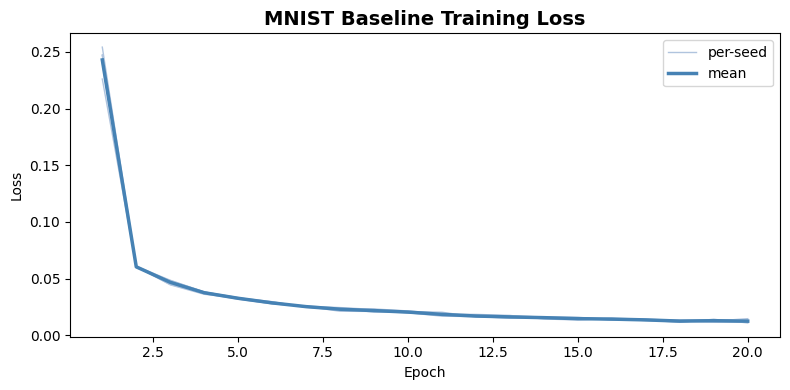

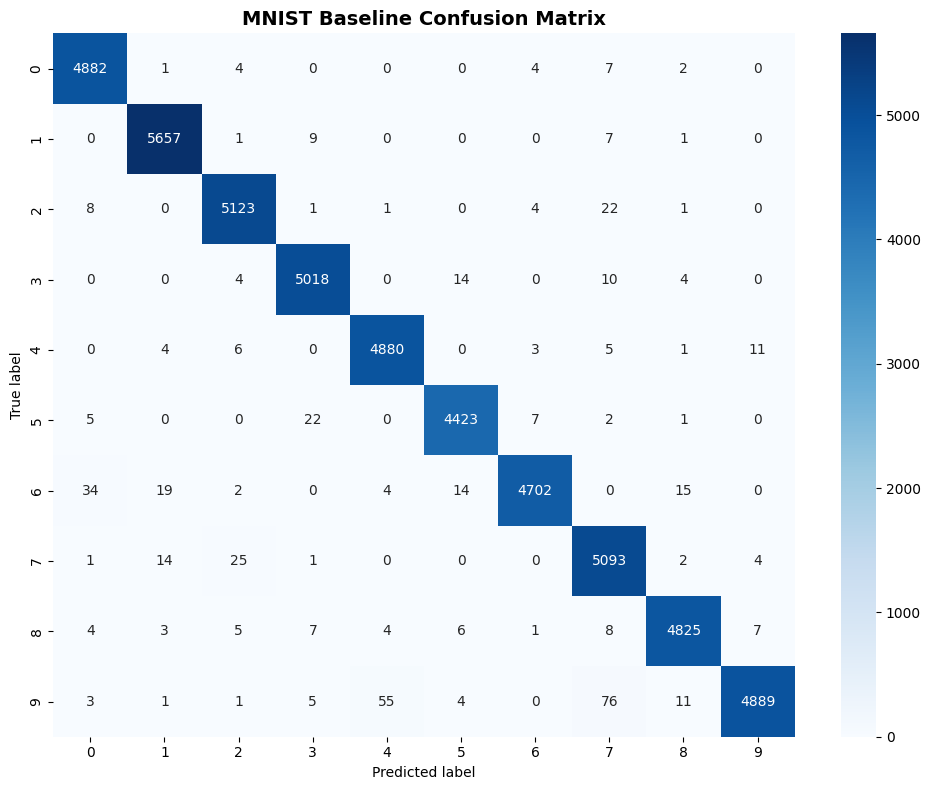

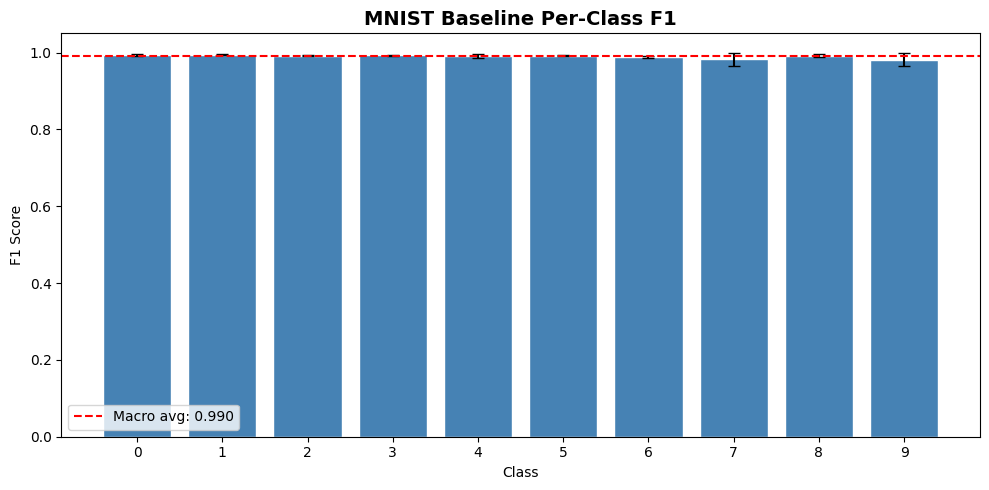


  Baseline on FULL CIFAR-10  (5 seeds)


100%|██████████| 170M/170M [58:49<00:00, 48.3kB/s]   


  seed 42   | acc  80.81% | macro-F1 0.8044 | saved baseline_cifar10_seed42_model.pth
  seed 123  | acc  80.58% | macro-F1 0.8091 | saved baseline_cifar10_seed123_model.pth
  seed 456  | acc  81.12% | macro-F1 0.8099 | saved baseline_cifar10_seed456_model.pth
  seed 789  | acc  80.67% | macro-F1 0.8064 | saved baseline_cifar10_seed789_model.pth
  seed 1011 | acc  81.47% | macro-F1 0.8124 | saved baseline_cifar10_seed1011_model.pth

-- CIFAR-10 BASELINE (mean +/- std over 5 seeds) --
  Top-1 Accuracy :  80.93%  +/- 0.33
  Macro F1       : 0.8084  +/- 0.0028

  Per-class F1:
    airplane     0.8102 +/- 0.0169
    automobile   0.9055 +/- 0.0100
    bird         0.7262 +/- 0.0060
    cat          0.6465 +/- 0.0177
    deer         0.7908 +/- 0.0051
    dog          0.7386 +/- 0.0138
    frog         0.8508 +/- 0.0081
    horse        0.8468 +/- 0.0114
    ship         0.8903 +/- 0.0054
    truck        0.8786 +/- 0.0100


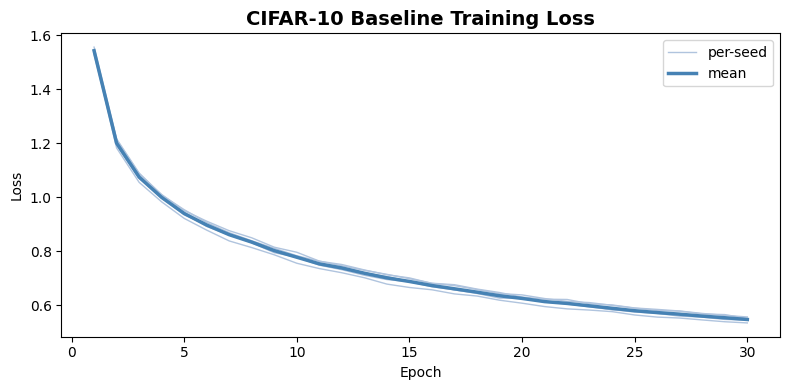

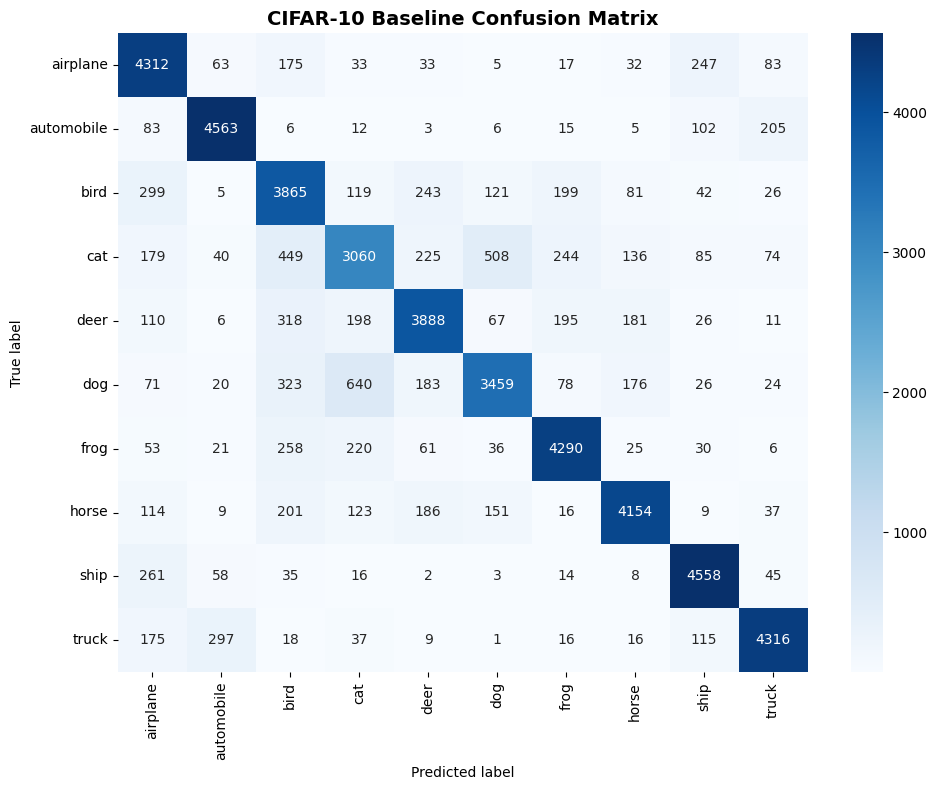

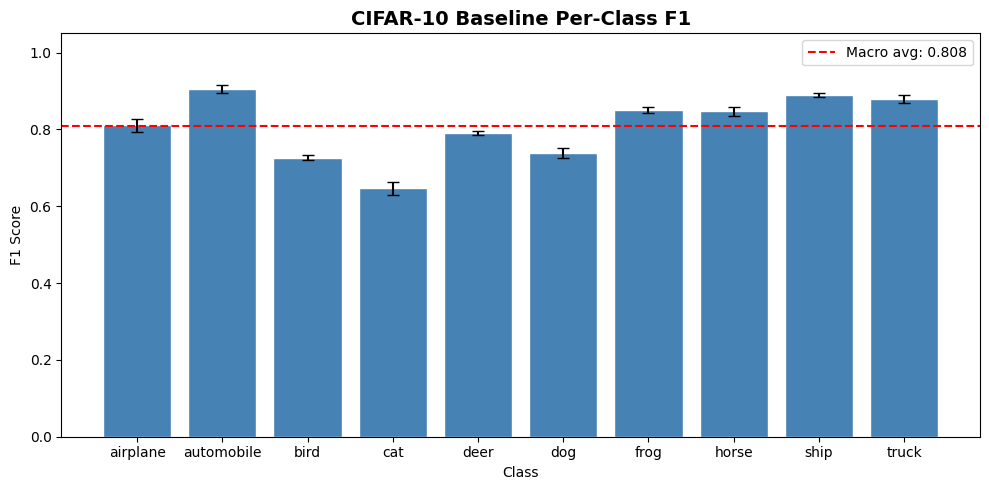

In [25]:
# -- 12. RUN EVERYTHING -----------------------------------------------------

# --- MNIST ---  (20 epochs)
mnist_results = run_baseline(
    dataset_name = "MNIST",
    loader_fn    = get_mnist_loaders,
    in_channels  = 1,                       # grayscale
    class_names  = MNIST_CLASSES,
    num_epochs   = 20,
)

# --- CIFAR-10 ---  (30 epochs)
cifar_results = run_baseline(
    dataset_name = "CIFAR-10",
    loader_fn    = get_cifar10_loaders,
    in_channels  = 3,                       # RGB
    class_names  = CIFAR10_CLASSES,
    num_epochs   = 30,
)